# 09 — Durable Execution and Interrupts

## Goal

Understand how LangGraph checkpoints enable execution to pause and resume.

We will learn:

- what an interrupt is
- how execution state is checkpointed before pausing
- how to resume the same thread
- why resume is different from starting the task again
- how this supports human approval and long-running workflows

We will continue using SQLite for local development.

RETRY
- run the failed step again

RESTART
- start the whole workflow from the beginning

RESUME
- continue from persisted execution state

## Small Graph First

In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END


class ApprovalState(TypedDict):
    request: str
    approved: bool | None
    result: str | None
    
def prepare(state: ApprovalState):
    return {
        "result": f"Prepared action for: {state['request']}"
    }

In [2]:
from langgraph.types import interrupt

def approval_step(state: ApprovalState):
    decision = interrupt(
        {
            "question": "Approve this action?",
            "request": state["request"],
        }
    )

    return {
        "approved": bool(decision)
    }

In [3]:
def execute(state: ApprovalState):
    if state["approved"]:
        return {
            "result": f"Executed: {state['request']}"
        }

    return {
        "result": f"Rejected: {state['request']}"
    }

In [4]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver

db_path = Path("../data/durable_execution.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

connection = sqlite3.connect(
    db_path,
    check_same_thread=False,
)

checkpointer = SqliteSaver(connection)

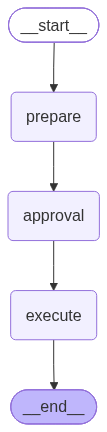

In [5]:
builder = StateGraph(ApprovalState)

builder.add_node("prepare", prepare)
builder.add_node("approval", approval_step)
builder.add_node("execute", execute)

builder.add_edge(START, "prepare")
builder.add_edge("prepare", "approval")
builder.add_edge("approval", "execute")
builder.add_edge("execute", END)

graph = builder.compile(
    checkpointer=checkpointer
)

graph

In [9]:
config = {
    "configurable": {
        "thread_id": "approval-thread-001"
    }
}

result = graph.invoke(
    {
        "request": "Publish the research report",
        "approved": None,
        "result": None,
    },
    config=config,
)

print(result)

{'request': 'Publish the research report', 'approved': None, 'result': 'Prepared action for: Publish the research report', '__interrupt__': [Interrupt(value={'question': 'Approve this action?', 'request': 'Publish the research report'}, id='90e7204531dc742fc9f2f214a8eaca39')]}


In [10]:
state = graph.get_state(config)

print(state)

StateSnapshot(values={'request': 'Publish the research report', 'approved': None, 'result': 'Prepared action for: Publish the research report'}, next=('approval',), config={'configurable': {'thread_id': 'approval-thread-001', 'checkpoint_ns': '', 'checkpoint_id': '1f1acd4c-6b5e-620e-8001-40ae41964c49'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-10T05:02:09.204891+00:00', parent_config={'configurable': {'thread_id': 'approval-thread-001', 'checkpoint_ns': '', 'checkpoint_id': '1f1acd4c-6b4e-6e91-8000-dcbf3a5df623'}}, tasks=(PregelTask(id='b4a0436a-1cc0-0192-edbf-bb7e7a219b47', name='approval', path=('__pregel_pull', 'approval'), error=None, interrupts=(Interrupt(value={'question': 'Approve this action?', 'request': 'Publish the research report'}, id='90e7204531dc742fc9f2f214a8eaca39'),), state=None, result=None),), interrupts=(Interrupt(value={'question': 'Approve this action?', 'request': 'Publish the research report'}, id='90e7204531dc742fc9f2f214a8ea

In [11]:
state.next

('approval',)

In [12]:
state.tasks

(PregelTask(id='b4a0436a-1cc0-0192-edbf-bb7e7a219b47', name='approval', path=('__pregel_pull', 'approval'), error=None, interrupts=(Interrupt(value={'question': 'Approve this action?', 'request': 'Publish the research report'}, id='90e7204531dc742fc9f2f214a8eaca39'),), state=None, result=None),)

In [13]:
from langgraph.types import Command

resumed = graph.invoke(
    Command(resume=True),
    config=config,
)

print(resumed)


{'request': 'Publish the research report', 'approved': True, 'result': 'Executed: Publish the research report'}


## Prove Process Restart

In [19]:
restart_config = {
    "configurable": {
        "thread_id": "approval-thread-restart1"
    }
}

graph.invoke(
    {
        "request": "Deploy version 2 to production",
        "approved": None,
        "result": None,
    },
    config=restart_config,
)

{'request': 'Deploy version 2 to production',
 'approved': None,
 'result': 'Prepared action for: Deploy version 2 to production',
 '__interrupt__': [Interrupt(value={'question': 'Approve this action?', 'request': 'Deploy version 2 to production'}, id='c082d75b9499c27e3ed8d6c5dd9ab0f4')]}

NOTE: 
Stop the kernel here. Restart and run the following to test for durable execution

In [6]:
restart_config = {
    "configurable": {
        "thread_id": "approval-thread-restart1"
    }
}

In [8]:
from langgraph.types import Command

graph.invoke(
    Command(resume=True),
    config=restart_config,
)

{'request': 'Deploy version 2 to production',
 'approved': True,
 'result': 'Executed: Deploy version 2 to production'}

In [9]:
state = graph.get_state(restart_config)

print(state.values)
print(state.next)

{'request': 'Deploy version 2 to production', 'approved': True, 'result': 'Executed: Deploy version 2 to production'}
()


## Reject instead of approve

In [12]:
reject_config = {
    "configurable": {
        "thread_id": "approval-thread-reject"
    }
}

graph.invoke(
    {
        "request": "Deploy version 2 to production",
        "approved": None,
        "result": None,
    },
    config=reject_config,
)

{'request': 'Deploy version 2 to production',
 'approved': None,
 'result': 'Prepared action for: Deploy version 2 to production',
 '__interrupt__': [Interrupt(value={'question': 'Approve this action?', 'request': 'Deploy version 2 to production'}, id='ab98dac3b6690d4b844934a7a9966c41')]}

In [13]:
result = graph.invoke(
    Command(resume=False),
    config=reject_config,
)

print(result)

{'request': 'Deploy version 2 to production', 'approved': False, 'result': 'Rejected: Deploy version 2 to production'}


## Durable execution is not the same thing as background execution

### Background execution

The agent keeps running without the client connection remaining open.

### Durable execution

Execution state survives pauses, failures, or process restarts and can later
continue from persisted state.

In [15]:
history = list(
    graph.get_state_history(restart_config)
)

for i, checkpoint in enumerate(history):
    print(f"\nCheckpoint {i}")
    print("next:", checkpoint.next)
    print("values:", checkpoint.values)


Checkpoint 0
next: ()
values: {'request': 'Deploy version 2 to production', 'approved': True, 'result': 'Executed: Deploy version 2 to production'}

Checkpoint 1
next: ('execute',)
values: {'request': 'Deploy version 2 to production', 'approved': True, 'result': 'Prepared action for: Deploy version 2 to production'}

Checkpoint 2
next: ('approval',)
values: {'request': 'Deploy version 2 to production', 'approved': None, 'result': 'Prepared action for: Deploy version 2 to production'}

Checkpoint 3
next: ('prepare',)
values: {'request': 'Deploy version 2 to production', 'approved': None, 'result': None}

Checkpoint 4
next: ('__start__',)
values: {}


## Connect this to Deep Agent

1. Start from the current research Deep Agent
2. Add SQLite checkpointing
3. Run a real research thread
4. Insert an approval interrupt before an expensive/deep phase
5. Persist the interrupted state
6. Restart the kernel/process
7. Resume the same research thread
8. Observe that earlier work is preserved
9. Connect the same thread_id into hosting.py
10. Understand how this will behave in the deployed Hosted Agent

In [6]:
class ResearchWorkflowState(TypedDict):
    query: str
    initial_result: str | None
    approved: bool | None
    final_result: str | None

In [7]:
from deep_agents_foundry import build_research_agent

research_agent = build_research_agent()

C:\Users\shchitt\Downloads\Projects\deep-agents-on-foundry\src\deep_agents_foundry\tools.py:13: ExperimentalWarning: WebSearchTool is currently in preview and is subject to change. This preview is provided without a service-level agreement, and we don't recommend it for production workloads. Certain features might not be supported or might have constrained capabilities. For more information, see https://azure.microsoft.com/support/legal/preview-supplemental-terms
  return WebSearchTool()


In [8]:
def final_text(message) -> str:
    content = message.content

    if isinstance(content, str):
        return content

    if isinstance(content, list):
        return "".join(
            block.get("text", "")
            for block in content
            if isinstance(block, dict)
            and block.get("type") == "text"
        )

    return str(content)

In [9]:
def initial_research(state: ResearchWorkflowState):
    result = research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": f"""
Research this topic using current authoritative sources:

{state["query"]}

Do a focused first pass only.

Return:
1. key facts
2. important unknowns
3. areas that deserve deeper investigation

Do not perform the full deep-dive yet.
""",
                }
            ]
        }
    )

    return {
        "initial_result": final_text(result["messages"][-1])
    }

In [10]:
from langgraph.types import interrupt


def request_approval(state: ResearchWorkflowState):
    decision = interrupt(
        {
            "question": "Proceed with the deeper research pass?",
            "initial_result": state["initial_result"],
        }
    )

    return {
        "approved": bool(decision)
    }

In [11]:
def deep_research(state: ResearchWorkflowState):
    if not state["approved"]:
        return {
            "final_result": state["initial_result"]
        }

    result = research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": f"""
Original research question:

{state["query"]}

Initial research findings:

{state["initial_result"]}

Now perform the deeper research pass.

Investigate:
- identity and RBAC
- scaling/runtime lifecycle
- session behavior
- observability
- deployment implications
- enterprise operational risks
- important trade-offs

Use current authoritative sources.

Produce a final synthesis that is decision-useful for an enterprise AI architect.
""",
                }
            ]
        }
    )

    return {
        "final_result": final_text(result["messages"][-1])
    }

In [12]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END


db_path = Path("../data/research_durable.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

connection = sqlite3.connect(
    db_path,
    check_same_thread=False,
)

checkpointer = SqliteSaver(connection)

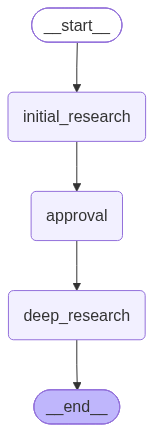

In [14]:
builder = StateGraph(ResearchWorkflowState)

builder.add_node("initial_research", initial_research)
builder.add_node("approval", request_approval)
builder.add_node("deep_research", deep_research)

builder.add_edge(START, "initial_research")
builder.add_edge("initial_research", "approval")
builder.add_edge("approval", "deep_research")
builder.add_edge("deep_research", END)

durable_research_agent = builder.compile(
    checkpointer=checkpointer
)
durable_research_agent

In [15]:
thread_config = {
    "configurable": {
        "thread_id": "foundry-hosted-agent-research-002"
    }
}


result = durable_research_agent.invoke(
    {
        "query": (
            "What are the most important architectural trade-offs of running "
            "custom Deep Agents as Microsoft Foundry Hosted Agents for enterprise workloads?"
        ),
        "initial_result": None,
        "approved": None,
        "final_result": None,
    },
    config=thread_config,
)

print(result)


{'query': 'What are the most important architectural trade-offs of running custom Deep Agents as Microsoft Foundry Hosted Agents for enterprise workloads?', 'initial_result': '## 1) Key facts (focused first pass)\n\n- **What “Foundry Hosted Agents” are (architecturally):** you package your custom agent (any framework / your own code) as a **container image**; Foundry Agent Service runs it on **Microsoft-managed infrastructure**, exposes a **dedicated endpoint**, and handles **scaling, session state persistence, observability, and lifecycle management** while your code handles request orchestration and tool/model calls. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))\n\n- **Isolation + state model differs from typical “stateless web app” hosting:**\n  - Hosted agents are designed around **per-session isolation** (Microsoft positions it as “per-session sandboxes” with **persistent filesystem**). ([devblogs.microsoft.com](https://devb

In [16]:
state = durable_research_agent.get_state(thread_config)

print("NEXT:", state.next)
print("APPROVED:", state.values["approved"])
print()
print(state.values["initial_result"])

NEXT: ('approval',)
APPROVED: None

## 1) Key facts (focused first pass)

- **What “Foundry Hosted Agents” are (architecturally):** you package your custom agent (any framework / your own code) as a **container image**; Foundry Agent Service runs it on **Microsoft-managed infrastructure**, exposes a **dedicated endpoint**, and handles **scaling, session state persistence, observability, and lifecycle management** while your code handles request orchestration and tool/model calls. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))

- **Isolation + state model differs from typical “stateless web app” hosting:**
  - Hosted agents are designed around **per-session isolation** (Microsoft positions it as “per-session sandboxes” with **persistent filesystem**). ([devblogs.microsoft.com](https://devblogs.microsoft.com/foundry/introducing-the-new-hosted-agents-in-foundry-agent-service-secure-scalable-compute-built-for-agents/))
  - Foundry per

In [19]:
from IPython.display import display, Markdown
display(Markdown(state.values["initial_result"]))



## 1) Key facts (focused first pass)

- **What “Foundry Hosted Agents” are (architecturally):** you package your custom agent (any framework / your own code) as a **container image**; Foundry Agent Service runs it on **Microsoft-managed infrastructure**, exposes a **dedicated endpoint**, and handles **scaling, session state persistence, observability, and lifecycle management** while your code handles request orchestration and tool/model calls. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))

- **Isolation + state model differs from typical “stateless web app” hosting:**
  - Hosted agents are designed around **per-session isolation** (Microsoft positions it as “per-session sandboxes” with **persistent filesystem**). ([devblogs.microsoft.com](https://devblogs.microsoft.com/foundry/introducing-the-new-hosted-agents-in-foundry-agent-service-secure-scalable-compute-built-for-agents/))
  - Foundry persists **$HOME** and uploaded files across turns/idle periods, and supports file persistence patterns (e.g., `$HOME` and `/files` endpoint). ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))  
  **Trade-off implication:** you get “agent-native” state handling, but you must design carefully around what state is stored there (sensitivity, retention, replayability, and portability).

- **Identity is first-class and opinionated:**
  - On deployment, Foundry assigns a **dedicated Microsoft Entra ID “agent identity”** that the agent can use to access models/tools/downstream Azure services (RBAC). ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))  
  **Trade-off implication:** stronger enterprise alignment (RBAC, managed identity style patterns) vs. less freedom than fully custom identity plumbing (and new governance work: scoping, auditing, privilege boundaries).

- **Protocol/compatibility trade-off (client interface):**
  - Hosted agents can expose an **OpenAI-compatible `/responses` endpoint** (and also an “Invocations” protocol for other payloads / webhooks). ([learn.microsoft.com](https://learn.microsoft.com/en-us/agent-framework/hosting/foundry-hosted-agent))  
  **Trade-off implication:** easier client integration (standard SDKs) but you may conform to Foundry’s session lifecycle semantics and request/response constraints.

- **Compute control is partial (you pick resources, platform runs it):**
  - You can **specify CPU/memory** for the sandbox, but Foundry controls the runtime environment, scaling behavior, and session provisioning. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))  
  **Trade-off implication:** less infra toil, but also fewer low-level knobs than self-hosting (AKS/Container Apps), and possible “platform-shaped” performance constraints.

- **Enterprise networking has a “platform + BYO VNet” dimension:**
  - Foundry Agent Service supports **private networking options including BYO VNet**, and Microsoft explicitly calls out that in BYO VNet you are responsible for **delegated subnet sizing, IP allocation planning, and understanding traffic flows/capacity signals**. ([azure.microsoft.com](https://azure.microsoft.com/en-us/products/ai-foundry/agent-service/))  
  **Trade-off implication:** you can meet strict egress/segmentation requirements, but networking becomes a non-trivial architecture and capacity-planning exercise.

- **Managed “agent platform” features are bundled:**
  - Microsoft positions Foundry Agent Service as including **built-in identity, memory, and observability**, reducing “infrastructure glue.” ([azure.microsoft.com](https://azure.microsoft.com/en-us/products/ai-foundry/agent-service/))  
  **Trade-off implication:** faster time-to-prod vs. coupling to Foundry’s operational model (telemetry, debugging workflow, platform limits/quotas).

---

## 2) Important unknowns (that materially affect enterprise architecture decisions)

- **Precise isolation guarantees and threat model details** (beyond marketing terms): e.g., what is guaranteed about cross-session isolation, data remnants, side channels, and how persistence is scoped/secured.

- **Hard limits and quotas that shape workload fit**: concurrency ceilings, session duration/timeouts, filesystem size limits, request size/streaming constraints, rate limits, and “long-running” behavior under interruption (some docs mention resiliency/replay, but the operational boundaries need pinning down). ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))

- **Networking specifics for “no public egress / private endpoints” deployments**: what traffic still hits Microsoft-managed control planes, how DNS is handled, what outbound dependencies exist (model endpoints, toolboxes, telemetry), and how to prove this for auditors. ([azure.microsoft.com](https://azure.microsoft.com/en-us/products/ai-foundry/agent-service/))

- **Data handling + compliance posture details**: retention of session data/files, encryption at rest/in transit specifics, log redaction controls, regional availability and data residency constraints (the docs reference “Limits, pricing, and availability” but a focused compliance matrix isn’t captured in the snippets above). ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))

- **Cost model under real enterprise usage patterns**: “scale to zero” exists conceptually, but the full bill of materials typically includes model/tool usage, cold start penalties, baseline overhead, and observability ingestion. (Needs validation against pricing + metrics guidance.) ([devblogs.microsoft.com](https://devblogs.microsoft.com/foundry/introducing-the-new-hosted-agents-in-foundry-agent-service-secure-scalable-compute-built-for-agents/))

- **Operational maturity questions**: upgrade/rollback mechanics for container images, blue/green or canary support, version pinning for runtimes, and incident response hooks (SRE readiness).

---

## 3) Areas that deserve deeper investigation (next-pass deep dive targets)

1. **Security architecture & governance**
   - Agent identity (Entra) lifecycle, RBAC patterns, least-privilege templates, secret management approach, audit logging.
   - Isolation + persistence: what gets persisted, where, and how to enforce tenant/user boundaries.

2. **Networking & connectivity for regulated enterprises**
   - BYO VNet reference architectures, IP consumption model, subnet sizing guidance, private egress/no-public-egress validation steps, and integration with enterprise firewalls/proxies. ([github.com](https://github.com/MicrosoftDocs/azure-ai-docs/blob/main/articles/foundry/agents/concepts/agents-networking-deep-dive.md))

3. **State management strategy**
   - When to use `$HOME`/`/files` vs external durable stores (Blob/Cosmos/etc.), backup/restore, retention, and portability (avoiding “state trapped in platform semantics”). ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))

4. **Performance & reliability engineering**
   - Cold start characteristics, throughput scaling behavior, latency budgets, retry/replay semantics, and how “long-lived work resiliently” behaves under failures. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/hosted-agents))

5. **Protocol/API integration choices**
   - Trade-offs of Responses protocol (OpenAI-compatible) vs Invocations protocol: client ecosystem fit, auth context propagation, and compatibility with existing gateway/API management patterns. ([learn.microsoft.com](https://learn.microsoft.com/en-us/agent-framework/hosting/foundry-hosted-agent))

If you want, in the next step I can convert these into a structured trade-off matrix (control vs. ops burden vs. security/compliance vs. cost vs. performance) specifically comparing **Hosted Agents vs Container Apps/AKS vs in-process agents** for typical enterprise workload archetypes.

In [ ]:
state = durable_research_agent.get_state(thread_config)

print("NEXT:", state.next)

NEXT: ('approval',)



In [22]:
from langgraph.types import Command

result = durable_research_agent.invoke(
    Command(resume=True),
    config=thread_config,
)

print(final_text(result["messages"][-1]) if "messages" in result else result["final_result"])

Below is a decision-oriented synthesis of the *architectural trade-offs* when you run **custom Deep Agents** (containerized code + tools/models) as **Microsoft Foundry Hosted Agents** for **enterprise workloads**, based on current Microsoft documentation and reference material.

---

## 1) Identity & RBAC: “agent identity” is powerful—but opinionated

### What you gain
- **First-class enterprise identity for agents**: Foundry provisions an **agent identity in Microsoft Entra ID** and uses it for downstream tool authentication, so your agent can call Azure resources without embedding secrets (managed, audited, least-privilege RBAC patterns). ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/agent-identity))
- **Token handling is platform-managed**: when the agent invokes a tool, Foundry performs a multi-step OAuth token exchange; developers *don’t manage tokens directly*. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/c

In [23]:
history = list(
    durable_research_agent.get_state_history(thread_config)
)

for i, checkpoint in enumerate(history):
    print(f"\nCHECKPOINT {i}")
    print("next:", checkpoint.next)

    values = checkpoint.values

    print("has initial result:", bool(values.get("initial_result")))
    print("approved:", values.get("approved"))
    print("has final result:", bool(values.get("final_result")))


CHECKPOINT 0
next: ()
has initial result: True
approved: True
has final result: True

CHECKPOINT 1
next: ('deep_research',)
has initial result: True
approved: True
has final result: False

CHECKPOINT 2
next: ('approval',)
has initial result: True
approved: None
has final result: False

CHECKPOINT 3
next: ('initial_research',)
has initial result: False
approved: None
has final result: False

CHECKPOINT 4
next: ('__start__',)
has initial result: False
approved: None
has final result: False


# What we learned

## Persistence

Stores graph state across invocations and process restarts.

## Interrupt

Intentionally suspends execution and requests external input.

## Resume

Continues the previously checkpointed execution rather than starting again.

## Durable execution

Combines graph state, checkpointing, and resumability so long-running workflows
can survive pauses and runtime failures.

Durability is not just a reliability feature.

It can also avoid repeated model calls, tool calls, latency, and side effects.